In [31]:
%pip install xgboost -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# library import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [33]:
# import the data 
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

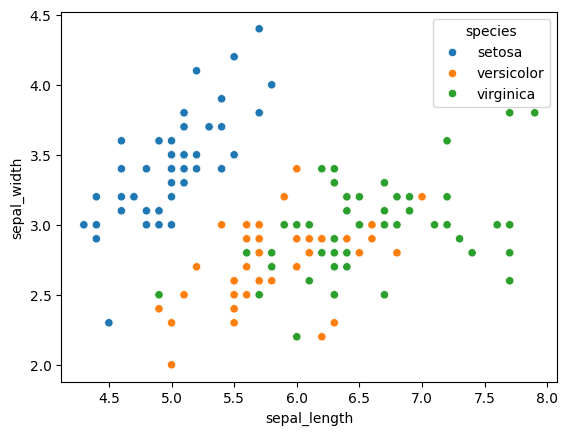

In [34]:
# plot the data 

sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species')

In [35]:
# split the data in to x & y
y = df['species']
x = df.drop('species', axis=1)

# encoding 

le = LabelEncoder()
y = le.fit_transform(y)
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [36]:
%%time
# # train the decision tree model 

dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

dt_y_pred = dt.predict(X_test)

print(accuracy_score(y_test,dt_y_pred))
print(precision_score(y_test,dt_y_pred,average='micro'))
print(recall_score(y_test,dt_y_pred,average='micro'))
print(f1_score(y_test,dt_y_pred,average='micro'))

1.0
1.0
1.0
1.0
CPU times: total: 15.6 ms
Wall time: 16 ms


In [37]:
%%time
# # train the random forest model 

rfc = RandomForestClassifier()
rfc.fit(X_train,y_train)

rfc_y_pred = rfc.predict(X_test)

print(accuracy_score(y_test,rfc_y_pred))
print(precision_score(y_test,rfc_y_pred,average='micro'))
print(recall_score(y_test,rfc_y_pred,average='micro'))
print(f1_score(y_test,rfc_y_pred,average='micro'))

1.0
1.0
1.0
1.0
CPU times: total: 312 ms
Wall time: 311 ms


In [38]:
%%time
# # train the decision tree model 

xgb = XGBClassifier()
xgb.fit(X_train,y_train)

xgb_y_pred = xgb.predict(X_test)

print(accuracy_score(y_test,xgb_y_pred))
print(precision_score(y_test,xgb_y_pred,average='micro'))
print(recall_score(y_test,xgb_y_pred,average='micro'))
print(f1_score(y_test,xgb_y_pred,average='micro'))

1.0
1.0
1.0
1.0
CPU times: total: 938 ms
Wall time: 144 ms


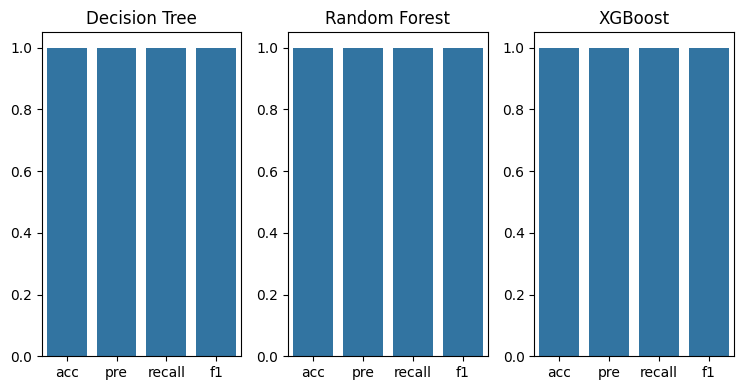

In [41]:
# make a bar plot of each metric with respect to model
plt.figure(figsize=(10,4))
plt.subplot(1,4,1)
sns.barplot(x=['acc','pre','recall','f1'],y=[accuracy_score(y_test,dt_y_pred),precision_score(y_test,dt_y_pred,average='micro'),recall_score(y_test,dt_y_pred,average='micro'),f1_score(y_test,dt_y_pred,average='micro')])
plt.title('Decision Tree')
plt.subplot(1,4,2)
sns.barplot(x=['acc','pre','recall','f1'],y=[accuracy_score(y_test,rfc_y_pred),precision_score(y_test,rfc_y_pred,average='micro'),recall_score(y_test,rfc_y_pred,average='micro'),f1_score(y_test,rfc_y_pred,average='micro')])
plt.title('Random Forest')
plt.subplot(1,4,3)
sns.barplot(x=['acc','pre','recall','f1'],y=[accuracy_score(y_test,xgb_y_pred),precision_score(y_test,xgb_y_pred,average='micro'),recall_score(y_test,xgb_y_pred,average='micro'),f1_score(y_test,xgb_y_pred,average='micro')])
plt.title('XGBoost')

plt.tight_layout()
plt.show()

In [42]:
df = sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [44]:
y = df['cut']
x = df.drop('cut', axis=1)

le = LabelEncoder()
y = le.fit_transform(y)
x['color'] = le.fit_transform(x['color'])
x['clarity'] = le.fit_transform(x['clarity'])


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [53]:
%%time
# # train the decision tree model 

dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

dt2_y_pred = dt.predict(x_test)

print(accuracy_score(y_test,dt2_y_pred))
print(precision_score(y_test,dt2_y_pred,average='micro'))
print(recall_score(y_test,dt2_y_pred,average='micro'))
print(f1_score(y_test,dt2_y_pred,average='micro'))

0.7156099369670004
0.7156099369670004
0.7156099369670004
0.7156099369670004
CPU times: total: 484 ms
Wall time: 504 ms


In [52]:
%%time
# # train the random forest model 

rfc = RandomForestClassifier()
rfc.fit(x_train,y_train)

rfc2_y_pred = rfc.predict(x_test)

print(accuracy_score(y_test,rfc2_y_pred))
print(precision_score(y_test,rfc2_y_pred,average='micro'))
print(recall_score(y_test,rfc2_y_pred,average='micro'))
print(f1_score(y_test,rfc2_y_pred,average='micro'))

0.7896737115313311
0.7896737115313311
0.7896737115313311
0.7896737115313311
CPU times: total: 12.5 s
Wall time: 12.8 s


In [54]:
%%time
# # train the decision tree model 

xgb = XGBClassifier()
xgb.fit(x_train,y_train)

xgb2_y_pred = xgb.predict(x_test)

print(accuracy_score(y_test,xgb2_y_pred))
print(precision_score(y_test,xgb2_y_pred,average='micro'))
print(recall_score(y_test,xgb2_y_pred,average='micro'))
print(f1_score(y_test,xgb2_y_pred,average='micro'))

0.803392658509455
0.803392658509455
0.803392658509455
0.803392658509455
CPU times: total: 13.8 s
Wall time: 2.46 s


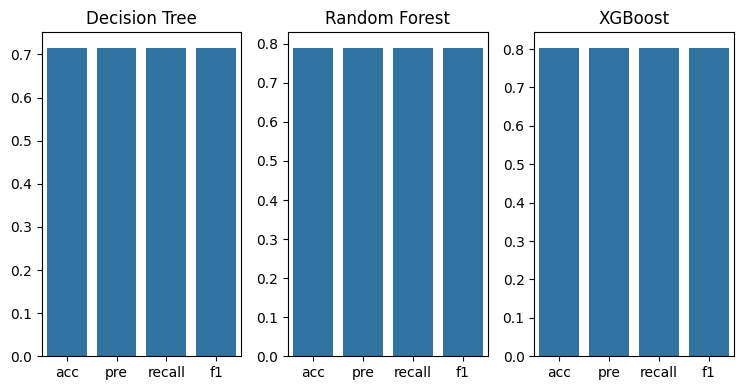

In [55]:
# make a bar plot of each metric with respect to model
plt.figure(figsize=(10,4))
plt.subplot(1,4,1)
sns.barplot(x=['acc','pre','recall','f1'],y=[accuracy_score(y_test,dt2_y_pred),precision_score(y_test,dt2_y_pred,average='micro'),recall_score(y_test,dt2_y_pred,average='micro'),f1_score(y_test,dt2_y_pred,average='micro')])
plt.title('Decision Tree')
plt.subplot(1,4,2)
sns.barplot(x=['acc','pre','recall','f1'],y=[accuracy_score(y_test,rfc2_y_pred),precision_score(y_test,rfc2_y_pred,average='micro'),recall_score(y_test,rfc2_y_pred,average='micro'),f1_score(y_test,rfc2_y_pred,average='micro')])
plt.title('Random Forest')
plt.subplot(1,4,3)
sns.barplot(x=['acc','pre','recall','f1'],y=[accuracy_score(y_test,xgb2_y_pred),precision_score(y_test,xgb2_y_pred,average='micro'),recall_score(y_test,xgb2_y_pred,average='micro'),f1_score(y_test,xgb2_y_pred,average='micro')])
plt.title('XGBoost')

plt.tight_layout()
plt.show()